In [6]:
from experiment.clustering import investigate_clusters, get_embeddings
from experiment.utils import TrainedModel, TrainedModelID, load_cuda_model, turn_cuda_into_custom
from neuralhydrology.datasetzoo import get_dataset
from neuralhydrology.datautils.utils import load_scaler

In [2]:
model = TrainedModel(TrainedModelID.EMB_20)

In [3]:
# get trained cuda model
(cuda_model, cfg) = load_cuda_model(config_file=model.cfg_path, run_dir=model.run_dir)

# turn it into a custom model
custom_lstm = turn_cuda_into_custom(cuda_model, cfg)

# get the embeddings from the model
embeddings = get_embeddings(custom_lstm, cfg, model.run_dir)

/home/admin/Fine-Flood-Forecasts/experiment/utils.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(str(model_path), map_location='cpu') # load

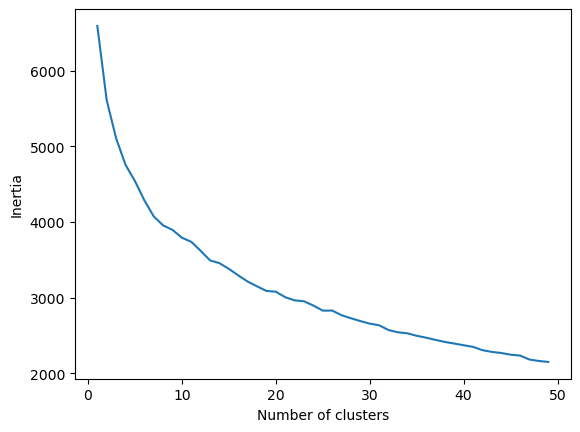

In [4]:
investigate_clusters(embeddings=embeddings)

In [7]:
# instead of getting embeddings, cluster directly on the basin attributes
scaler = load_scaler(model.run_dir)

dataset = get_dataset(cfg, is_train=False, period='test', scaler=scaler)


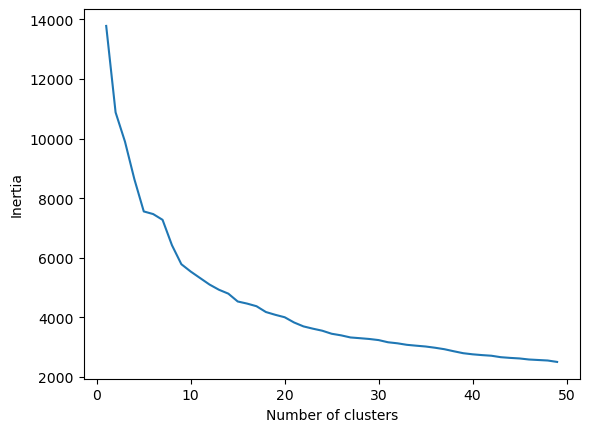

In [12]:
investigate_clusters(dataset._attributes)